In [65]:
from pathlib import Path

import pandas as pd
from acteval.describe.frequency import plot_agg_acts
from acteval.describe.transitions import _probs_plot
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

In [97]:
cmaps = {
    "home": (0.55, 0.71, 0.82),  # #8CB6D1 steel blue
    "work": (0.88, 0.36, 0.32),  # #E15C52 red
    "education": (0.96, 0.78, 0.26),  # #F5C742 golden yellow
    "shop": (0.61, 0.49, 0.78),  # #9C7DC7 purple
    "visit": (0.94, 0.53, 0.23),  # #F0873B amber
    "escort": (0.29, 0.75, 0.73),  # #4ABFBA teal
    "medical": (0.94, 0.53, 0.60),  # #F0879A rose
    "travel": (0.62, 0.62, 0.62),  # #9E9E9E mid grey
    "other": (0.71, 0.80, 0.48),  # #B5CC7A sage green
}

batch_paths = {
    "PT scenario": Path("../logs/actvae/extrapolation"),
    "Baseline": Path("../logs/actvae/cvae"),
}

# find data
target_schedules = pd.read_csv("../tmp/test_schedules.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv("../tmp/test_attributes.csv")

all_schedules = pd.read_csv("~/Data/foundata/out/nts/2023/activities.csv")
acts = list(all_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

all_attributes = pd.read_csv(
    "~/Data/foundata/out/nts/2023/attributes_binned.csv"
)


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    if not versions:
        return path.name, path
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "eval" / "domains" / "distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "eval" / "domains" / "distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }

/tmp/ipykernel_1629630/2629761923.py:29: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  all_attributes = pd.read_csv(


In [81]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/actvae/extrapolation/extrapolation_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/cvae/cvae_nrun0/version_0


In [111]:
attributes["Baseline Suburban"] = attributes["Baseline"][
    (attributes["Baseline"].hh_zone == "suburban")
    & (attributes["Baseline"].access_egress_distance == "≤3.376")
]

schedules["Baseline Suburban"] = schedules["Baseline"][
    schedules["Baseline"].pid.isin(attributes["Baseline Suburban"].pid)
]

attributes["Target Suburban"] = all_attributes[
    (all_attributes.hh_zone == "suburban")
    & (all_attributes.access_egress_distance == "≤3.376")
]

schedules["Target Suburban"] = all_schedules[
    all_schedules.pid.isin(attributes["Target Suburban"].pid)
]

In [83]:
def build_distance_tables(batch_paths):
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / "eval" / "domains" / "distances.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "EMD")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    # distances_combined = distances_combined.set_index(
    #     pd.MultiIndex.from_tuples(distances_combined.index)
    # )

    return distances_combined


order = ["participations", "transitions", "timing", "feasibility", "creativity"]
df = build_distance_tables(batch_paths)
print(df.loc[order].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{2}{r}{PT scenario} & \multicolumn{2}{r}{Baseline} \\
 & EMD & var & EMD & var \\
domain &  &  &  &  \\
\midrule
participations & 0.106 & 0.000 & 0.132 & 0.000 \\
transitions & 0.012 & 0.000 & 0.006 & 0.000 \\
timing & 0.040 & 0.000 & 0.058 & 0.000 \\
feasibility & 0.019 & 0.000 & 0.020 & 0.000 \\
creativity & 0.001 & 0.000 & 0.030 & 0.000 \\
\bottomrule
\end{tabular}



PT scenario                Baseline              
                       EMD           var       EMD           var
domain                                                          
creativity        0.000954  1.191517e-07  0.030166  7.698165e-08
feasibility       0.019165  1.585243e-05  0.019925  3.873522e-05
participations    0.106020  7.117979e-06  0.132332  1.992688e-04
timing            0.040402  5.733703e-07  0.057808  4.746851e-06
transitions       0.012419  5.715096e-07  0.005790  1.247979e-06

In [84]:
def group_tables(batch_paths):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / "eval" / "groups" / "distances.csv"
        ).set_index(["domain", "feature"])
        descriptions = pd.read_csv(
            path / "eval" / "groups" / "descriptions.csv"
        ).set_index(["domain", "feature"])

        columns = set(distances.columns)
        columns = list(
            columns - set(["observed", "unit", "mean", "std", "sub_pop"])
        )

        print(name, columns)

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return (
        distances_combined.loc[index],
        variances_combined,
        descriptions_combined.loc[index],
    )


dist_dist, dist_std, dist_desc = group_tables(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

PT scenario ['extrapolation_nrun1', 'extrapolation_nrun2', 'extrapolation_nrun0']
Baseline ['cvae_nrun3', 'cvae_nrun2', 'cvae_nrun1', 'cvae_nrun0', 'cvae_nrun4']
\begin{tabular}{lrrrr}
\toprule
 & \multicolumn{2}{r}{PT scenario} & \multicolumn{2}{r}{Baseline} \\
 & mean & var & mean & var \\
feature &  &  &  &  \\
\midrule
lengths & 0.249 & 0.000 & 0.334 & 0.001 \\
pair participation rate & 0.007 & 0.000 & 0.006 & 0.000 \\
participation rate & 0.062 & 0.000 & 0.057 & 0.000 \\
2-gram & 0.019 & 0.000 & 0.012 & 0.000 \\
3-gram & 0.007 & 0.000 & 0.003 & 0.000 \\
4-gram & 0.011 & 0.000 & 0.002 & 0.000 \\
durations & 0.026 & 0.000 & 0.047 & 0.000 \\
joint-durations & 0.066 & 0.000 & 0.076 & 0.000 \\
start times & 0.022 & 0.000 & 0.045 & 0.000 \\
start-durations & 0.048 & 0.000 & 0.063 & 0.000 \\
consecutive & 0.019 & 0.000 & 0.020 & 0.000 \\
invalid & 0.019 & 0.000 & 0.020 & 0.000 \\
not home based & 0.000 & 0.000 & 0.000 & 0.000 \\
conservatism & 0.001 & 0.000 & 0.030 & 0.000 \\
homogeneity

In [118]:
all_trip_rate = all_schedules.groupby("pid").size().mean() - 1
target_trip_rate = target_schedules.groupby("pid").size().mean() - 1
baseline_trip_rate = schedules["Baseline"].groupby("pid").size().mean() - 1
baseline_suburban_trip_rate = (
    schedules["Baseline Suburban"].groupby("pid").size().mean() - 1
)
scenarios_suburban_trip_rate = (
    schedules["PT scenario"].groupby("pid").size().mean() - 1
)
print(f"All trip rate: {all_trip_rate:.2f}")
print(f"Target trip rate: {target_trip_rate:.2f}")
print(f"Baseline trip rate: {baseline_trip_rate:.2f}")
print(f"Baseline Suburban trip rate: {baseline_suburban_trip_rate:.2f}")
print(f"Scenario trip rate: {scenarios_suburban_trip_rate:.2f}")
print()
target_delta = target_trip_rate - all_trip_rate
baseline_delta = baseline_suburban_trip_rate - all_trip_rate
scenario_delta = scenarios_suburban_trip_rate - all_trip_rate
print(f"Target delta: {target_delta:.2f}")
print(f"Scenario delta: {scenario_delta:.2f}")
print(f"Baseline delta: {baseline_delta:.2f}")

print()
baseline_ae = abs(baseline_suburban_trip_rate - target_trip_rate)
scenario_ae = abs(scenarios_suburban_trip_rate - target_trip_rate)
print(f"Scenario AE: {scenario_ae:.2f}")
print(f"Baseline AE: {baseline_ae:.2f}")

All trip rate: 2.93
Target trip rate: 2.60
Baseline trip rate: 2.79
Baseline Suburban trip rate: 2.74
Scenario trip rate: 2.80

Target delta: -0.33
Scenario delta: -0.13
Baseline delta: -0.19

Scenario AE: 0.20
Baseline AE: 0.15


In [ ]:
def build_trips_table(batch_paths, n):
    combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = (
            pd.read_csv(
                path / "eval" / "features_by_category" / "distances.csv"
            )
            .set_index(["domain", "feature", "segment", "label", "cat"])
            .loc[("participations", "lengths", "sequence lengths")]
        )
        descriptions = (
            pd.read_csv(
                path / "eval" / "features_by_category" / "descriptions.csv"
            )
            .set_index(["domain", "feature", "segment", "label", "cat"])
            .loc[("participations", "lengths", "sequence lengths")]
        )

        exclude = ["observed", "unit"]
        runs = [c for c in distances.columns if c not in exclude]

        observed = descriptions["observed"] - n
        expected = descriptions[runs].mean(axis=1) - n

        combined[("NTS 2023", "expected")] = descriptions["observed"] - 1
        combined[("NTS 2023", "response")] = observed
        combined[(name, "response")] = expected

        # combined[(name, "EMD")] = distances[runs].mean(axis=1)
        combined[(name, "AE")] = abs(expected - observed)

    combined = combined.sort_index(axis=0, level=0, sort_remaining=True)
    combined = combined.loc[combined[("Baseline", "AE")] < 3]

    filtered = combined.drop(
        combined.index[combined.index.get_level_values("cat") == "unknown"]
    )

    return filtered


n = target_schedules.groupby("pid").size().mean()
table = build_trips_table(batch_paths, n)

for label in table.index.get_level_values("label").unique():
    print(f"Label: {label}")
    print(
        table.loc[label]
        .style.highlight_min(
            axis=1,
            props="textbf:--rwrap;",
            subset=[("PT scenario", "AE"), ("Baseline", "AE")],
        )
        .format(precision=3)
        .to_latex()
    )
table

Label: access_egress_distance
\begin{tabular}{lrrrrrr}
 & ('NTS 2023', 'expected') & ('NTS 2023', 'response') & ('PT scenario', 'response') & ('PT scenario', 'AE') & ('Baseline', 'response') & ('Baseline', 'AE') \\
cat &  &  &  &  &  &  \\
≤3.376 & 2.656 & -0.275 & -0.155 & 0.180 & -0.166 & \textbf{0.109} \\
\end{tabular}

Label: age
\begin{tabular}{lrrrrrr}
 & ('NTS 2023', 'expected') & ('NTS 2023', 'response') & ('PT scenario', 'response') & ('PT scenario', 'AE') & ('Baseline', 'response') & ('Baseline', 'AE') \\
cat &  &  &  &  &  &  \\
10-21 & 2.534 & -0.397 & -0.184 & 0.485 & -0.182 & \textbf{0.215} \\
21-32 & 2.763 & -0.168 & -0.130 & 0.326 & -0.158 & \textbf{0.010} \\
32-40 & 3.072 & 0.141 & -0.156 & \textbf{0.134} & -0.132 & 0.274 \\
40-48 & 3.254 & 0.323 & -0.175 & \textbf{0.035} & -0.122 & 0.445 \\
48-54 & 3.117 & 0.186 & -0.119 & \textbf{0.159} & -0.121 & 0.307 \\
54-61 & 3.089 & 0.158 & -0.090 & \textbf{0.100} & -0.112 & 0.271 \\
61-68 & 3.049 & 0.118 & -0.126 & \textbf{0.2

(NTS 2023, expected)  \
label                  cat                                 
access_egress_distance ≤3.376                   2.655889   
age                    10-21                    2.533527   
                       21-32                    2.762934   
                       32-40                    3.072091   
                       40-48                    3.253501   
                       48-54                    3.116516   
                       54-61                    3.088997   
                       61-68                    3.048699   
                       68-75                    2.998861   
                       >75                      2.792070   
                       ≤10                      2.670017   
day                    friday                   3.018335   
                       monday                   2.908734   
                       saturday                 2.918976   
                       sunday                   2.752523   
                       thursday                 2.971408   
                       tuesday                  2.946086   
                       wednesday                2.993387   
employment             ft-employed              2.952235   
                       other                    3.239729   
                       pt-employed              3.223037   
                       retired                  2.948123   
                       student                  2.525335   
                       unemployed               3.129630   
hh_income              22316-32118              2.953865   
                       32118-44107              2.933322   
                       44107-68887              3.029272   
                       >68887                   2.955958   
                       ≤22316                   2.781341   
hh_zone                suburban                 2.765314   
sex                    female                   2.973912   
                       male                     2.883900   
vehicles               0                        2.499068   
                       1                        2.946953   
                       2                        3.063442   
                       3                        3.015472   
                       4                        2.593525   

                                    (NTS 2023, response)  \
label                  cat                                 
access_egress_distance ≤3.376                  -0.274840   
age                    10-21                   -0.397203   
                       21-32                   -0.167795   
                       32-40                    0.141361   
                       40-48                    0.322772   
                       48-54                    0.185787   
                       54-61                    0.158268   
                       61-68                    0.117970   
                       68-75                    0.068132   
                       >75                     -0.138659   
                       ≤10                     -0.260712   
day                    friday                   0.087606   
                       monday                  -0.021996   
                       saturday                -0.011753   
                       sunday                  -0.178207   
                       thursday                 0.040678   
                       tuesday                  0.015356   
                       wednesday                0.062658   
employment             ft-employed              0.021506   
                       other                    0.309000   
                       pt-employed              0.292307   
                       retired                  0.017394   
                       student                 -0.405394   
                       unemployed               0.198900   
hh_income              22316-32118              0.023136   
                       32118-44107              0.002592   
               

In [85]:
from acteval.describe.times import durations_by_act, start_times_by_act
from acteval.describe.utils import _to_population
from matplotlib.figure import Axes, Figure


def time_plot(schedules, **kwargs) -> Figure:
    names = list(schedules.keys())
    pop = schedules[names[0]]
    acts = pop.act.value_counts().sort_values(ascending=False).index.tolist()
    acts.remove("home")
    n_acts = len(acts)
    rows = len(names)

    cmaps = kwargs.pop("cmaps", {})

    fig, axs = plt.subplots(
        rows,
        n_acts,
        figsize=kwargs.pop("figsize", (12, 5)),
        sharex=False,
        sharey=False,
    )

    for i, (name, y) in enumerate(schedules.items()):

        axs[i, 0].set_ylabel(name, fontsize=10, rotation=90)

        _joint_time_plot(_to_population(y), axs[i], acts, cmaps=cmaps)

    for ax in axs[-1]:
        ax.set_xlabel("Start times", fontsize=8)
        ax.set_xticks(
            [240, 480, 720, 960, 1200, 1440],
            labels=["04:00", "08:00", "12:00", "16:00", "20:00", "24:00"],
            rotation=90,
            fontsize=8,
        )

    for ax, title in zip(axs[:, 0], names):
        ax.text(
            -1,
            0.5,
            title,
            transform=ax.transAxes,
            fontsize=10,
            rotation=90,
            va="center",
            ha="center",
        )

    for ax, act in zip(axs[0], acts):
        ax.set_title(act.title(), fontsize=9)

    return fig


def _joint_time_plot(
    population,
    axs: Axes,
    acts: list[str],
    cmaps: dict,
    xmin: int = 240,
    xmax: int = 1441,
    ymin: int = 0,
    ymax: int = 960,
    xstep: int = 60,
    ystep: int = 60,
):
    pop = _to_population(population)
    start_feats = start_times_by_act(pop, bin_size=None)
    dur_feats = durations_by_act(pop, bin_size=None)

    start_bins = list(range(xmin, xmax, xstep))
    duration_bins = list(range(ymin, ymax, ystep))

    for i, act in enumerate(acts):
        cmap = cmaps.get(act)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        if act not in start_feats.data:
            continue
        act_starts = start_feats.data[act][0]
        act_durations = dur_feats.data[act][0]
        axs[i].hist2d(
            x=act_starts,
            y=act_durations,
            bins=(start_bins, duration_bins),
            cmap=cmap,
            cmin=1,
        )
    axs[0].set_ylabel("Durations", fontsize=8)
    axs[0].set_yticks(
        [0, 240, 480, 720, 960],
        labels=["00:00", "04:00", "08:00", "12:00", "16:00"],
        fontsize=8,
    )

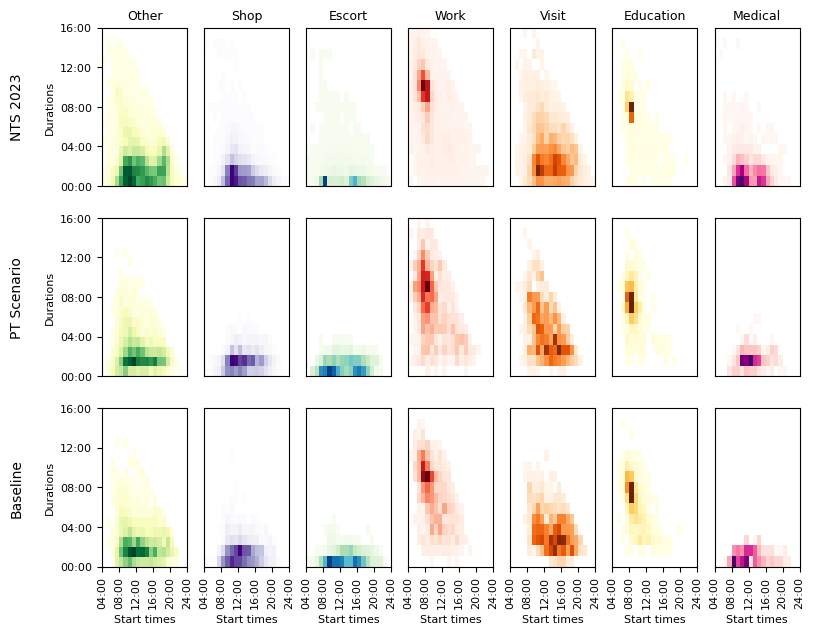

In [86]:
selected = {
    "NTS 2023": target_schedules,
    "PT Scenario": schedules["PT scenario"],
    "Baseline": schedules["Baseline Scenario"],
}

fig = time_plot(
    selected,
    figsize=(9, 7),
    observed_title="NTS 2023",
    cmaps={
        "work": "Reds",
        "education": "YlOrBr",
        "shop": "Purples",
        "visit": "Oranges",
        "escort": "GnBu",
        "medical": "RdPu",
        "travel": "Greys",
        "other": "YlGn",
    },
)
plt.subplots_adjust(wspace=0.2, hspace=0.2)

In [87]:
target_attributes.access_egress_distance.value_counts()

access_egress_distance
3.376-5.8       11191
9.15862-15.8    11175
≤3.376          11165
>15.8           11150
5.8-9.15862     11132
unknown           921
Name: count, dtype: int64

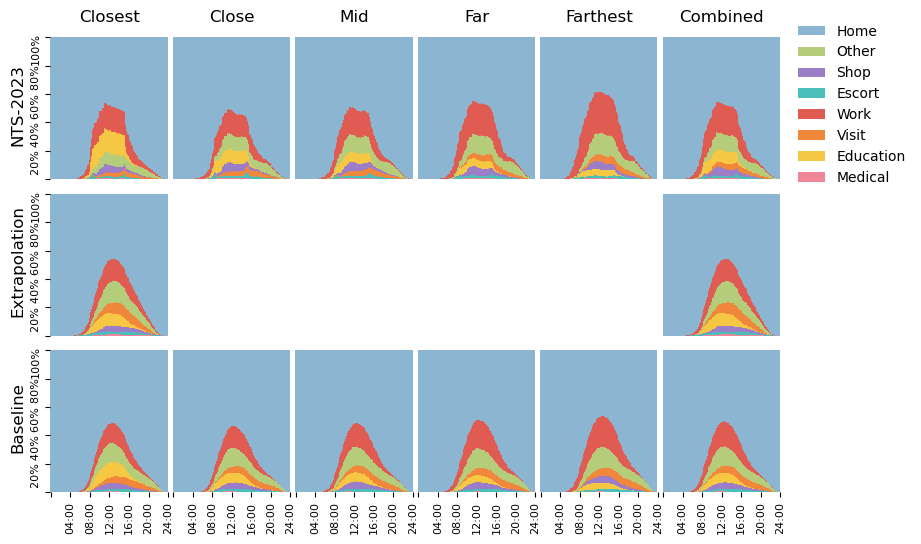

In [91]:
plot_schedules = {
    "NTS-2023": target_schedules,
    "Extrapolation": schedules["PT scenario"],
    "Baseline": schedules["Baseline"],
}
plot_attributes = {
    "NTS-2023": target_attributes,
    "Extrapolation": attributes["PT scenario"],
    "Baseline": attributes["Baseline"],
}

act_order = target_schedules.act.value_counts().index.to_list()
class_map = {n: i for i, n in enumerate(act_order)}

FILTER = ["≤3.376", "3.376-5.8", "5.8-9.15862", "9.15862-15.8", ">15.8"]
NAMES = ["Closest", "Close", "Mid", "Far", "Farthest"]

h = len(plot_schedules)
w = len(FILTER)
fig, axes = plt.subplots(
    h, w + 2, figsize=(w * 2.2, h * 2), sharex=False, sharey=False
)

for i, (name, scheds) in enumerate(plot_schedules.items()):

    splits = split_on(
        scheds, plot_attributes[name], by="access_egress_distance"
    )

    for j, f in enumerate(FILTER):
        axes[0, j].set_title(NAMES[j], fontsize=12)
        selected = splits.get(f)
        if selected is None:
            axes[i, j].axis("off")
            continue
        ax = plot_agg_acts(
            "",
            selected,
            class_map=class_map,
            ax=axes[i, j],
            legend=False,
            color=cmaps,
        )
        ax.set_title(None)
        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.set_yticks([])
        ax.set_xticks([])

        axes[-1, j].set_xticks(
            [i / 10 for i in [0, 240, 480, 720, 960, 1200, 1440]],
            labels=["", "04:00", "08:00", "12:00", "16:00", "20:00", "24:00"],
            rotation=90,
            fontsize=8,
        )

    axes[0, -2].set_title("Combined", fontsize=12)
    ax = plot_agg_acts(
        "",
        scheds,
        class_map=class_map,
        ax=axes[i, -2],
        legend=False,
        color=cmaps,
    )
    ax.set_title(None)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.set_yticks([])
    ax.set_xticks([])

    axes[-1, -2].set_xticks(
        [i / 10 for i in [0, 240, 480, 720, 960, 1200, 1440]],
        labels=["", "04:00", "08:00", "12:00", "16:00", "20:00", "24:00"],
        rotation=90,
        fontsize=8,
    )

    axes[i, 0].set_ylabel(name, fontsize=12)
    axes[i, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[i, 0].set_yticklabels(
        ["", "20% ", "40% ", "60% ", "80% ", "100%"], rotation=90, fontsize=8
    )

    axes[i, -1].axis("off")

elements = [Patch(facecolor=cmaps[act], label=act.title()) for act in act_order]
axes[0, -1].axis("off")
axes[0, -1].legend(handles=elements, loc="center left", frameon=False)

plt.subplots_adjust(wspace=0.04, hspace=0.05)

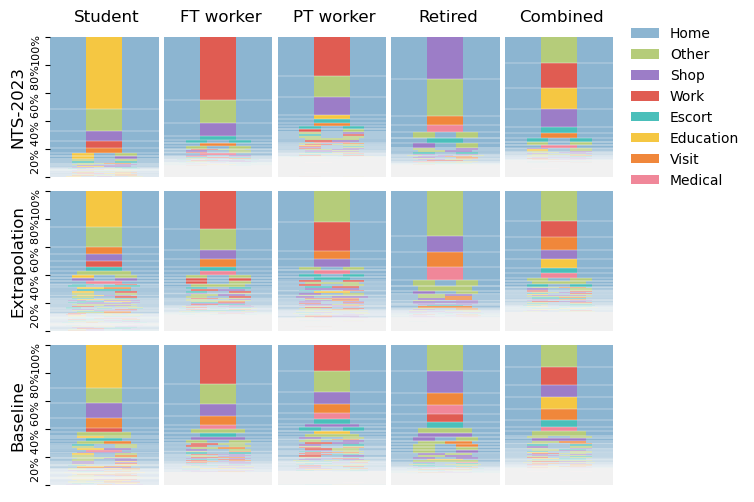

In [18]:
h = len(plot_schedules)
w = len(FILTER)
fig, axes = plt.subplots(
    h, w + 2, figsize=(w * 2.2, h * 2), sharex=False, sharey=False
)

for i, (name, scheds) in enumerate(plot_schedules.items()):

    splits = split_on(scheds, plot_attributes[name], by="employment")

    for j, f in enumerate(FILTER):
        axes[0, j].set_title(NAMES[j], fontsize=12)
        selected = splits[f]
        ax = _probs_plot("", selected, cmap=cmaps, ax=axes[i, j])
        ax.set_title(None)
        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.set_yticks([])
        ax.set_xticks([])

    axes[0, -2].set_title("Combined", fontsize=12)
    ax = _probs_plot("", scheds, cmap=cmaps, ax=axes[i, -2])
    ax.set_title(None)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.set_yticks([])
    ax.set_xticks([])

    axes[i, 0].set_ylabel(name, fontsize=12)
    axes[i, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[i, 0].set_yticklabels(
        ["", "20% ", "40% ", "60% ", "80% ", "100%"], rotation=90, fontsize=8
    )

    axes[i, -1].axis("off")

elements = [Patch(facecolor=cmaps[act], label=act.title()) for act in act_order]
axes[0, -1].axis("off")
axes[0, -1].legend(handles=elements, loc="center left", frameon=False)


plt.subplots_adjust(wspace=0, hspace=0)

In [64]:
target_attributes.columns

Index(['hid', 'pid', 'age', 'hh_size', 'hh_income', 'sex', 'dwelling',
       'ownership', 'vehicles', 'disability', 'education', 'can_wfh',
       'occupation', 'race', 'has_licence', 'relationship', 'employment',
       'country', 'source', 'year', 'month', 'day', 'hh_zone', 'weight',
       'access_egress_distance', 'max_temp_c', 'rain', 'avg_speed'],
      dtype='object')

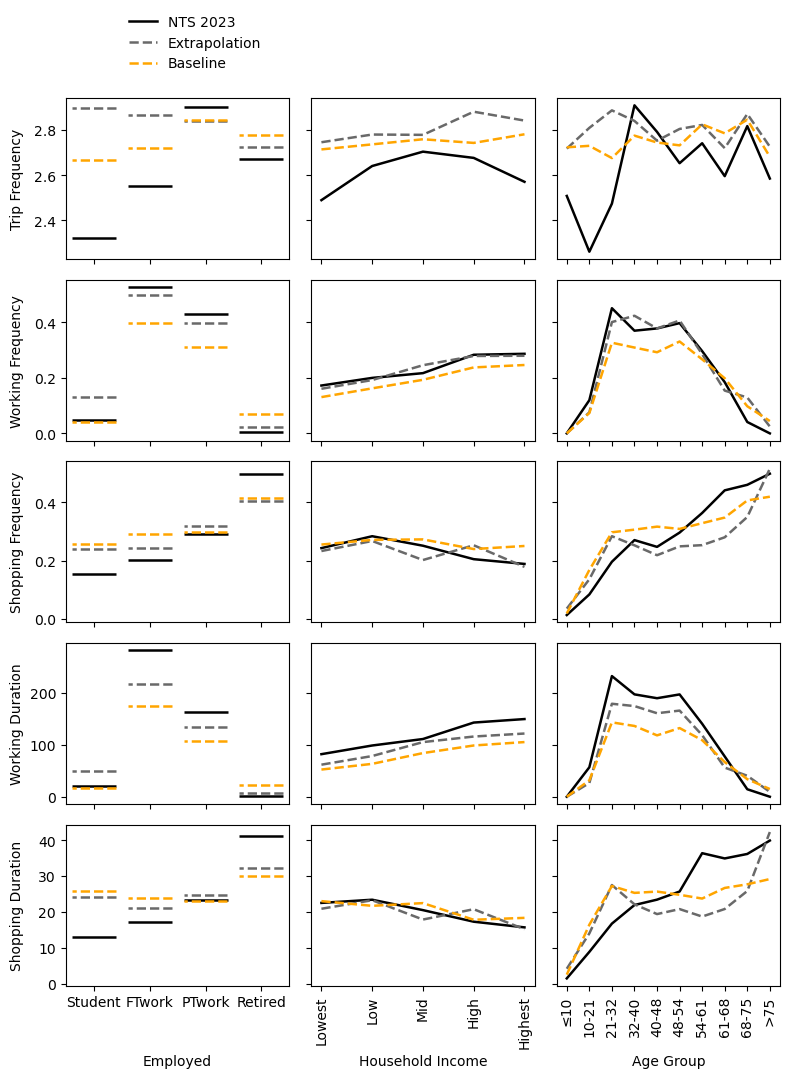

In [19]:
def duration(schedules, act="work"):
    if "duration" not in schedules.columns:
        durations = schedules.end - schedules.start
    else:
        durations = schedules.duration
    filtered = durations[schedules.act == act]
    n = schedules.pid.nunique()
    return filtered.sum(0) / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(schedules.loc[schedules.act == act]) / n


def plot_conditionals(
    schedules, attributes, target_schedules, target_attributes, figsize=(8, 10)
):
    WORK_STATUS = "employment"
    INCOME = "hh_income"
    AGE = "age"

    work_order = [
        # "retired",
        # "unemployed",
        "student",
        "ft-employed",
        "pt-employed",
        "retired",
    ]
    work_statuses = ["Student", "FTwork", "PTwork", "Retired"]

    age_order = [
        "≤10",
        "10-21",
        "21-32",
        "32-40",
        "40-48",
        "48-54",
        "54-61",
        "61-68",
        "68-75",
        ">75",
    ]
    ages = [
        "≤10",
        "10-21",
        "21-32",
        "32-40",
        "40-48",
        "48-54",
        "54-61",
        "61-68",
        "68-75",
        ">75",
    ]
    incomes = ["≤22316", "22316-32118", "32118-44107", "44107-68887", ">68887"]
    colours = [
        "black",
        "dimgray",
        "orange",
        "tomato",
        "dodgerblue",
        "grey",
        "black",
        "lightgrey",
        "pink",
        "green",
    ]
    styles = ["-", "--", "--", "--", "--", ":", ":", ":", ":", ":", ":"]
    LW = 1.8

    fig, axs = plt.subplots(5, 3, figsize=figsize, sharex="col", sharey="row")

    # ==============================
    # trips employment
    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[0][0]
    # change to bar plot
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Trip Frequency")
    ax.legend().remove()

    # ==============================
    # trips income
    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[0][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ==================================
    # trips age group
    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # =================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[1][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Working Frequency")
    ax.legend().remove()

    # =================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[1][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # =================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[2][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Shopping Frequency")
    ax.legend().remove()

    # =================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[2][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[3][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.legend().remove()
    ax.set_ylabel("Working Duration")

    # ====================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[3][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[4][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )

    ax.legend().remove()
    ax.set_xlim(-0.5, 3.5)

    ax.set_ylabel("Shopping Duration")
    ax.set_xlabel("Employed")
    ax.set_xticks(list(range(len(work_order))), work_statuses, rotation=0)

    # ====================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[4][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()
    ax.set_xlabel("Household Income")
    ax.set_xticks(
        [0, 1, 2, 3, 4],
        ["Lowest", "Low", "Mid", "High", "Highest"],
        rotation=90,
    )

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"NTS 2023": {}}
    for i, split in splits.items():
        data["NTS 2023"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][2]
    df.loc[age_order].plot.line(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()
    ax.set_xlabel("Age Group")
    ax.set_xticks(range(len(ages)), ages, rotation=90)

    # for ax in axs.flat:
    #     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.25, 1),
    )

    fig.align_ylabels(axs[:, 0])
    fig.align_xlabels(axs[-1, :])

    fig.tight_layout()


plot_conditionals(schedules, attributes, target_schedules, target_attributes)

In [119]:
batch_paths = {
    "KTDB (Korea)": Path("../logs/actvae/ktdb"),
    "NTS (UK) 2023": Path("../logs/actvae/cvae"),
    "LTDS (London)": Path("../logs/actvae/ltds"),
    "CMAP (Chicago)": Path("../logs/actvae/cmap"),
}
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/actvae/ktdb/ktdb_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/cvae/cvae_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/ltds/ltds_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/cmap/cmap_nrun0/version_1


In [123]:
targets = {
    "KTDB (Korea)": pd.read_csv("~/Data/foundata/out/ktdb/activities.csv"),
    "NTS (UK) 2023": pd.read_csv("~/Data/foundata/out/nts/2023/activities.csv"),
    "LTDS (London)": pd.read_csv("~/Data/foundata/out/ltds/activities.csv"),
    "CMAP (Chicago)": pd.read_csv("~/Data/foundata/out/cmap/activities.csv"),
}

In [ ]:
for k, atts in attributes.items():
    print(k, len(atts))

KTDB (Korea) 88905
NTS (UK) 2023 56734
LTDS (London) 37346
CMAP (Chicago) 17777


In [124]:
for k, scheds in schedules.items():
    target = targets[k]
    target_trip_rate = target.groupby("pid").size().mean() - 1
    trip_rate = scheds.groupby("pid").size().mean() - 1
    MAE = abs(trip_rate - target_trip_rate)
    print(k, trip_rate, target_trip_rate, MAE)

KTDB (Korea) 2.88559698554637 2.952128676677352 0.06653169113098212
NTS (UK) 2023 2.79130680015511 2.930729368632566 0.13942256847745638
LTDS (London) 2.661302415251968 2.81237615808922 0.15107374283725195
CMAP (Chicago) 3.6139393598469933 3.848849637171626 0.23491027732463277


In [62]:
order = ["participations", "transitions", "timing", "feasibility", "creativity"]
df = build_distance_tables(batch_paths)
print(df.loc[order].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{KTDB (Korea)} & \multicolumn{2}{r}{NTS (UK) 2023} & \multicolumn{2}{r}{LTDS (London)} & \multicolumn{2}{r}{CMAP (Chicago)} \\
 & EMD & var & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  &  &  \\
\midrule
participations & 0.095 & 0.000 & 0.132 & 0.000 & 0.099 & 0.000 & 0.164 & 0.000 \\
transitions & 0.006 & 0.000 & 0.006 & 0.000 & 0.011 & 0.000 & 0.010 & 0.000 \\
timing & 0.046 & 0.000 & 0.058 & 0.000 & 0.038 & 0.000 & 0.042 & 0.000 \\
feasibility & 0.036 & 0.000 & 0.020 & 0.000 & 0.017 & 0.000 & 0.104 & 0.001 \\
creativity & 0.025 & 0.000 & 0.030 & 0.000 & 0.004 & 0.000 & 0.003 & 0.000 \\
\bottomrule
\end{tabular}



KTDB (Korea)               NTS (UK) 2023                \
                        EMD           var           EMD           var   
domain                                                                  
creativity         0.024852  5.156020e-06      0.030166  7.698165e-08   
feasibility        0.036362  5.787746e-05      0.019925  3.873522e-05   
participations     0.095165  4.816285e-04      0.132332  1.992688e-04   
timing             0.045603  1.086523e-05      0.057808  4.746851e-06   
transitions        0.006461  3.568136e-07      0.005790  1.247979e-06   

               LTDS (London)               CMAP (Chicago)                
                         EMD           var            EMD           var  
domain                                                                   
creativity          0.003803  3.660299e-07       0.002549  7.124560e-07  
feasibility         0.017051  4.752174e-05       0.103707  5.409479e-04  
participations      0.098696  1.409361e-04       0.163802  1.979053e-04  
timing              0.038435  8.191465e-06       0.042406  4.828468e-05  
transitions         0.011260  8.143699e-07       0.010236  5.619904e-07

In [ ]:
dist_dist, dist_std, dist_desc = group_tables(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

KTDB (Korea) ['ktdb_nrun3', 'ktdb_nrun1', 'ktdb_nrun2', 'ktdb_nrun4', 'ktdb_nrun0']
NTS (UK) 2023 ['cvae_nrun3', 'cvae_nrun2', 'cvae_nrun1', 'cvae_nrun0', 'cvae_nrun4']
LTDS (London) ['ltds_nrun0', 'ltds_nrun4', 'ltds_nrun3', 'ltds_nrun1', 'ltds_nrun2']
CMAP (Chicago) ['cmap_nrun0', 'cmap_nrun2', 'cmap_nrun3', 'cmap_nrun1', 'cmap_nrun4']
\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{KTDB (Korea)} & \multicolumn{2}{r}{NTS (UK) 2023} & \multicolumn{2}{r}{LTDS (London)} & \multicolumn{2}{r}{CMAP (Chicago)} \\
 & mean & var & mean & var & mean & var & mean & var \\
feature &  &  &  &  &  &  &  &  \\
\midrule
lengths & 0.205 & 0.004 & 0.334 & 0.001 & 0.211 & 0.001 & 0.390 & 0.002 \\
pair participation rate & 0.006 & 0.000 & 0.006 & 0.000 & 0.010 & 0.000 & 0.012 & 0.000 \\
participation rate & 0.074 & 0.000 & 0.057 & 0.000 & 0.075 & 0.000 & 0.090 & 0.000 \\
2-gram & 0.016 & 0.000 & 0.012 & 0.000 & 0.024 & 0.000 & 0.023 & 0.000 \\
3-gram & 0.002 & 0.000 & 0.003 & 0.000 & 0.005 & 0